___

# Machine Learning in Geosciences ] 
Department of Applied Geoinformatics and Carthography, Charles University

Lukas Brodsky lukas.brodsky@natur.cuni.cz


## Exercise: Boosting Early Stopping technique

This notebook is dedicated to early stopping in boosting model . 

**Objective**:
Understand and implement different ensemble learning techniques—Bagging, Boosting, and Stacking—on a real-world dataset and compare their performance.

Tasks: 
1. Implement Gradient Boosting algorithm based on sklearn `GradientBoostingRegressor` class. 
2. Run boosting model with up to 200 estimators and measure testing error. 
3. Implement **Early stoping** procedure and plot the model performance with the indicator of the stopped boosting. 

In [2]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

In [4]:
# Data 
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

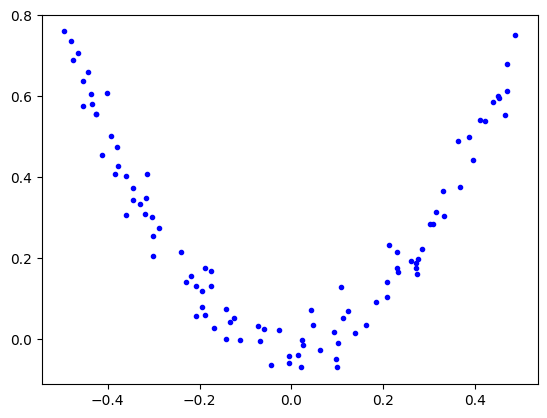

In [5]:
plt.plot(X, y, 'b.')

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=49)

### Gradient Boosting Model - error evolution

**To implement:** 

`
Algorithm GradientBoosting:
Initialize GradientBoostingRegressor with:
        max_depth = 2
        warm_start = True
        random_state = 42

    Initialize train_err as an empty list
    Initialize test_err as an empty list

    For n_estimators from 1 to 199 do:
        Set gbrt.n_estimators to n_estimators
        Train gbrt using X_train and y_train

        // Compute training error
        Predict y_train_pred using gbrt on X_train
        Compute train_error as mean squared error between y_train and y_train_pred
        Append train_error to train_err list

        // Compute test error
        Predict y_pred using gbrt on X_test
        Compute test_error as mean squared error between y_test and y_pred
        Append test_error to test_err list
End Algorithm
`

In [30]:
# Measure validation error of Boosting model with up to 200 estimators 
gbrt = GradientBoostingRegressor(max_depth=2, warm_start=True, random_state=42,n_estimators=200)

train_err = [] 
test_err = []

for n_estimators in range(1, 200):
    gbrt.n_estimators = n_estimators 
    gbrt.fit(X_train, y_train) 
    y_train_predict = gbrt.predict(X_train) 
    y_test_predict = gbrt.predict(X_test) 
    train_err.append(mean_squared_error(y_train, y_train_predict)) 
    test_err.append(mean_squared_error(y_test, y_test_predict))

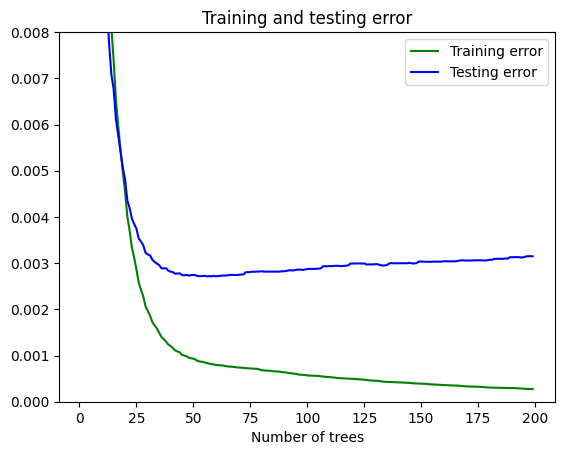

In [31]:
# Plot the evolution of the validation errors 
plt.plot(list(range(1, 200)), train_err, 'g-', label='Training error')
plt.plot(list(range(1, 200)), test_err, 'b-', label='Testing error')
plt.ylim(0.0, 0.008)
plt.xlabel('Number of trees')
plt.title('Training and testing error')
plt.legend()

## When to stop the model learning?

.

### Implement early stopping procedure with parameter testing error going up = 5 to find the best!

Stop after model testing error increses for **five times** in the iterative learning!

**Early stopping:**

`
Algorithm EarlyStopping:
    If val_error < min_val_error Then:
        Set min_val_error to val_error
        Set error_going_up to 0
    Else:
        Increment error_going_up by 1
        If error_going_up equals 5 Then:
            Break the loop
End Algorithm
`

array([ 0.18676157,  0.22294372,  0.01755707,  0.17465526,  0.06929893,
       -0.06888438, -0.05836412,  0.12986721,  0.63732423,  0.59447979,
        0.30643207,  0.28320074,  0.40294679,  0.0515729 ,  0.60427162,
        0.17649787,  0.23125967,  0.04184811,  0.55592656,  0.070826  ,
        0.19877932,  0.45490008,  0.27390973,  0.50260656,  0.61200235])

In [36]:
# Run the early stopping algorithm 
# mean_squared_error(y_test, y_pred)
# min_val_error = float("inf") 
# add error_going_up = 0 

mse = mean_squared_error(y_test, y_pred)
mve = min_val_error = float("inf")
 

In [37]:
print(gbrt.n_estimators)

1


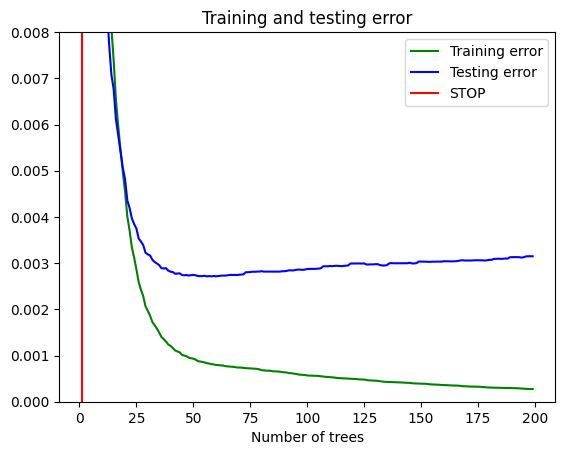

In [38]:
# Plot the evolution of the validation errors 
plt.plot(list(range(1, 200)), train_err, 'g-', label='Training error')
plt.plot(list(range(1, 200)), test_err, 'b-', label='Testing error')
plt.axvline(gbrt.n_estimators, color = 'red', label = 'STOP')
plt.ylim(0.0, 0.008)
plt.xlabel('Number of trees')
plt.title('Training and testing error')
plt.legend()

In [39]:
# model plot data 
X_sim = np.linspace(-0.5, 0.5, 100)
y_sim = gbrt.predict(X_sim.reshape(-1, 1)) 

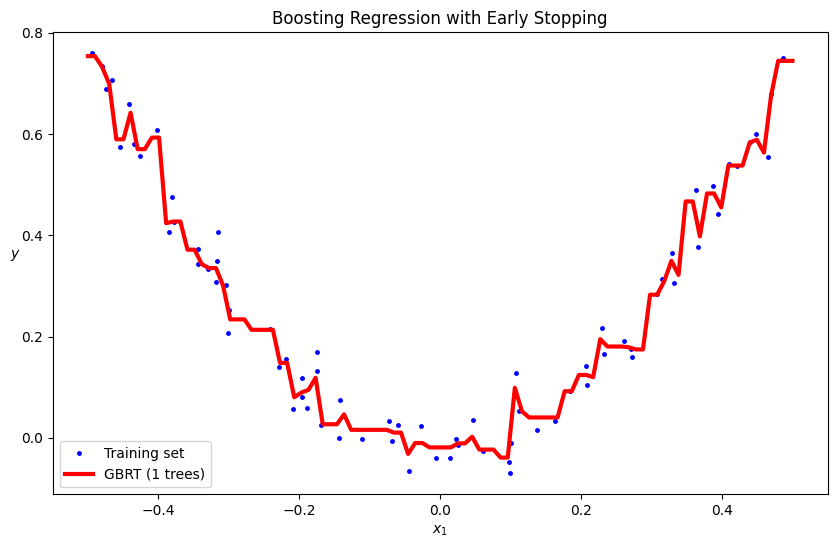

In [40]:
# Model prediction plot 
plt.figure(figsize=(10, 6))
plt.plot(X_train, y_train, "b.", markersize=5, label="Training set")
plt.plot(X_sim, y_sim, "r-", linewidth=3, label=f"GBRT ({gbrt.n_estimators} trees)")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.title("Boosting Regression with Early Stopping")
plt.legend()
plt.show() 
# plot data 
# plot model 